In [ ]:
import pandas as pd
import requests
from io import StringIO
import seaborn as sns

# Experiment 1: Identifying missing values in sensor and API logs

In [ ]:
# Load a sample dataset (eg. sensor logs with missing entries)
url_sensor = "https://thingspeak.com/channels/276330/feed.csv"  # Known to have partial gaps
response = requests.get(url_sensor)
df_sensor = pd.read_csv(StringIO(response.text))

In [ ]:
# Identify missing values
print("Missing values per column:\n", df_sensor.isnull().sum())
print("Dataset info:\n")

# df_sensor.info()

Missing values per column:
 created_at      0
entry_id        0
field1          0
field2          0
field3        100
field4        100
field5        100
field6        100
field7          0
field8          0
dtype: int64
Dataset info:



# Experiment 2: Imputing Missing Weather data from Web Scrapping

In [ ]:
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import numpy as np
import datetime

In [ ]:
# Query historical hourly weather data from Open-Meteo API
start_date = (datetime.datetime.today() - datetime.timedelta(days=3)).strftime('%Y-%m-%d')
end_date = datetime.datetime.today().strftime('%Y-%m-%d')

In [ ]:
weather_url = f"https://archive-api.open-meteo.com/v1/archive?latitude=47.61&longitude=-122.33&start_date={start_date}&end_date={end_date}&hourly=temperature_2m,relative_humidity_2m&timezone=auto"
res = requests.get(weather_url)
data = res.json()

In [ ]:
# Construct DataFrame from historical API data
weather_data = pd.DataFrame({
    'datetime': data['hourly']['time'],
    'temperature': data['hourly']['temperature_2m'],
    'humidity': data['hourly']['relative_humidity_2m']
})

In [ ]:
# Introduce artificial missing values to simulate sensor gaps (based on real drops)
weather_data.loc[5:8, 'humidity'] = np.nan
weather_data.loc[15:16, 'temperature'] = np.nan


In [ ]:
# Copy raw data for comparison
weather_data_raw = weather_data.copy()

In [ ]:
# Impute missing values
weather_data['temperature'].fillna(method='ffill', inplace=True)
weather_data['humidity'].fillna(method='bfill', inplace=True)

/tmp/ipython-input-3881379672.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  weather_data['temperature'].fillna(method='ffill', inplace=True)
/tmp/ipython-input-3881379672.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  weather_data['temperature'].fillna(method='ffill', inplace=True)
/tmp/ipython-input-3881379672.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an

In [ ]:
# Display comparison
print("Missing values before imputation: ", weather_data_raw.isnull().sum())
print("Missing values after imputation: ", weather_data.isnull().sum())

Missing values before imputation:  datetime        0
temperature    56
humidity       58
dtype: int64
Missing values after imputation:  datetime        0
temperature     0
humidity       54
dtype: int64


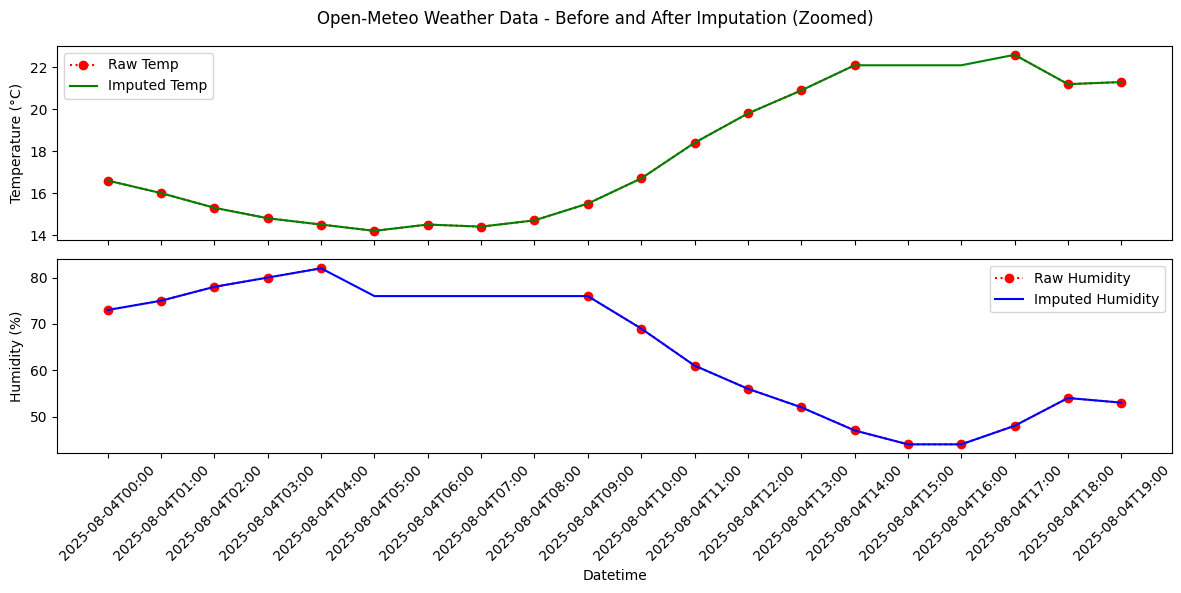

In [ ]:
# Visualize effect of imputation
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Limit data range to improve clarity
subset_range = 20  # Number of samples to display

# Ensure visible difference by marking NaNs explicitly
ax[0].plot(weather_data_raw['datetime'][:subset_range], weather_data_raw['temperature'][:subset_range], label='Raw Temp', linestyle='dotted', color='red', marker='o')
ax[0].plot(weather_data['datetime'][:subset_range], weather_data['temperature'][:subset_range], label='Imputed Temp', linestyle='solid', color='green')
ax[0].set_ylabel('Temperature (°C)')
ax[0].legend()

ax[1].plot(weather_data_raw['datetime'][:subset_range], weather_data_raw['humidity'][:subset_range], label='Raw Humidity', linestyle='dotted', color='red', marker='o')
ax[1].plot(weather_data['datetime'][:subset_range], weather_data['humidity'][:subset_range], label='Imputed Humidity', linestyle='solid', color='blue')
ax[1].set_ylabel('Humidity (%)')
ax[1].set_xlabel('Datetime')
ax[1].legend()

plt.suptitle('Open-Meteo Weather Data - Before and After Imputation (Zoomed)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Experiment 3: Time-Series Interpolation in IoT sensor streams

In [ ]:
url_iot = "https://thingspeak.com/channels/276330/feed.csv"
response_iot = requests.get(url_iot)
df_iot = pd.read_csv(StringIO(response_iot.text))

In [ ]:
# Select temperature-like signal and ensure numeric
df_iot['field1'] = pd.to_numeric(df_iot['field1'], errors='coerce')
df_iot['created_at'] = pd.to_datetime(df_iot['created_at'])


In [ ]:
# Drop rows with full NaNs in selected columns
df_interp_base = df_iot[['created_at', 'field1']].dropna(subset=['field1'])

In [ ]:
# Introduce missing data manually for interpolation testing
df_interp = df_interp_base.copy()
df_interp.loc[5:7, 'field1'] = np.nan

In [ ]:
# Apply different interpolation methods
interp_linear = df_interp['field1'].interpolate(method='linear')
interp_spline = df_interp['field1'].interpolate(method='spline', order=2)
interp_polynomial = df_interp['field1'].interpolate(method='polynomial', order=2)

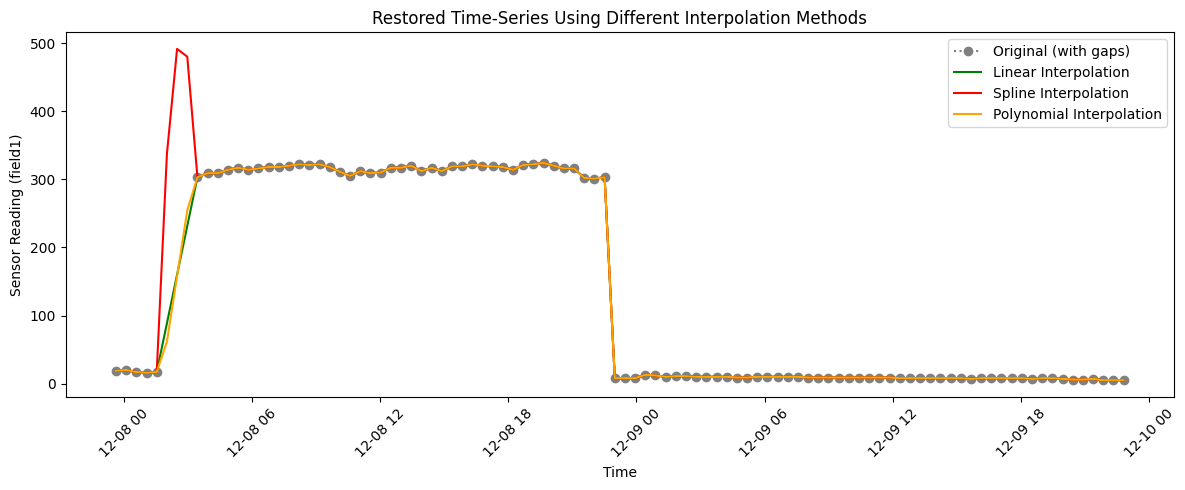

In [ ]:
# Plot comparisons
plt.figure(figsize=(12, 5))
plt.plot(df_interp['created_at'], df_interp['field1'], label='Original (with gaps)', linestyle='dotted', color='gray',marker="o")
plt.plot(df_interp['created_at'], interp_linear, label='Linear Interpolation', color='green')
plt.plot(df_interp['created_at'], interp_spline, label='Spline Interpolation', color='red')
plt.plot(df_interp['created_at'], interp_polynomial, label='Polynomial Interpolation', color='orange')

plt.title("Restored Time-Series Using Different Interpolation Methods")
plt.xlabel("Time")
plt.ylabel("Sensor Reading (field1)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Experiment 4: KNN Imputation in real-time Temperature feed

In [ ]:
from sklearn.impute import KNNImputer


In [ ]:
# Subset of ThingSpeak with selected fields (only those with valid data)
available_fields = [col for col in df_iot.columns if col.startswith('field')]
selected_fields = [f for f in available_fields if df_iot[f].dropna().shape[0] > 0][:2]  # use 2 non-empty fields


In [ ]:
# Filter and convert to numeric
df_knn = df_iot[selected_fields].copy()
df_knn = df_knn.apply(pd.to_numeric, errors='coerce')

In [ ]:
# Simulate 10-15% missing values in selected fields
np.random.seed(42)
for col in selected_fields:
    n_missing = int(len(df_knn) * 0.12)  # ~12% missing
    missing_indices = np.random.choice(df_knn.index, size=n_missing, replace=False)
    df_knn.loc[missing_indices, col] = np.nan


In [ ]:
# Use actual missing values
print("Simulated missing values in selected fields: ", df_knn.isnull().sum())
imputer = KNNImputer()
knn_array = imputer.fit_transform(df_knn)
df_knn_imputed = pd.DataFrame(knn_array, columns=selected_fields)

Simulated missing values in selected fields:  field1    12
field2    12
dtype: int64


In [ ]:
# 1. Display Missing Values Before and After
print("\nMissing values before imputation:\n", df_knn.isnull().sum())
print("Missing values after imputation:\n", df_knn_imputed.isnull().sum())


Missing values before imputation:
 field1    12
field2    12
dtype: int64
Missing values after imputation:
 field1    0
field2    0
dtype: int64


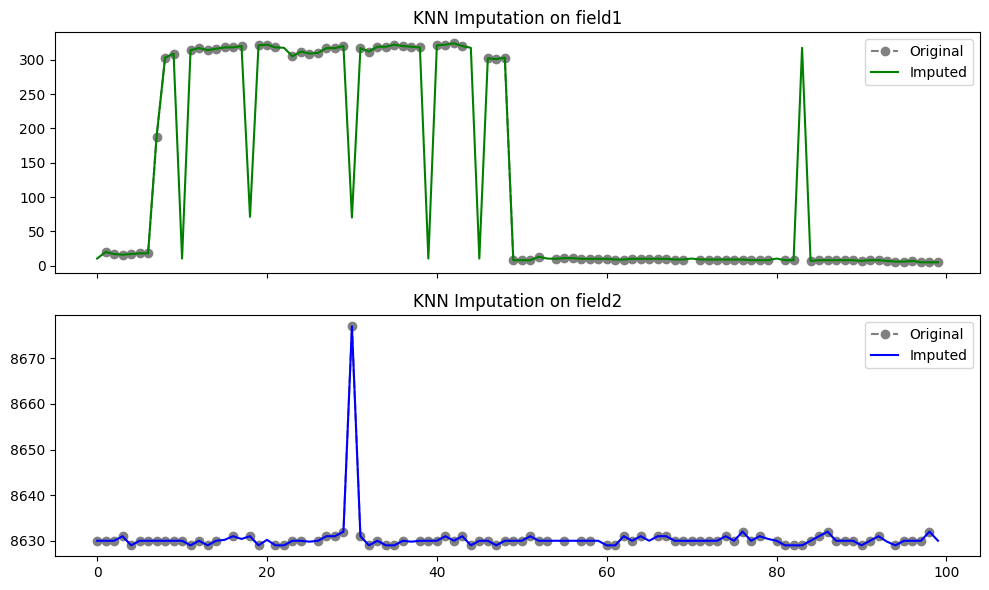

In [ ]:
# 2. Visualization of missing vs. imputed areas
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].plot(df_knn.index, df_knn[selected_fields[0]], label='Original', linestyle='--', color='gray', marker='o')
axs[0].plot(df_knn_imputed.index, df_knn_imputed[selected_fields[0]], label='Imputed', color='green')
axs[0].set_title(f"KNN Imputation on {selected_fields[0]}")
axs[0].legend()

axs[1].plot(df_knn.index, df_knn[selected_fields[1]], label='Original', linestyle='--', color='gray',marker = 'o')
axs[1].plot(df_knn_imputed.index, df_knn_imputed[selected_fields[1]], label='Imputed', color='blue')
axs[1].set_title(f"KNN Imputation on {selected_fields[1]}")
axs[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# 3. Correlation Observation
print(" Correlation before imputation: ", df_knn.corr())
print(" Correlation after imputation: ", df_knn_imputed.corr())

 Correlation before imputation:            field1    field2
field1  1.000000 -0.120317
field2 -0.120317  1.000000
 Correlation after imputation:            field1    field2
field1  1.000000 -0.060803
field2 -0.060803  1.000000


# Experiment 5: Visual diagnostics of Missingness Patterns

In [ ]:
import seaborn as sns
import missingno as msno

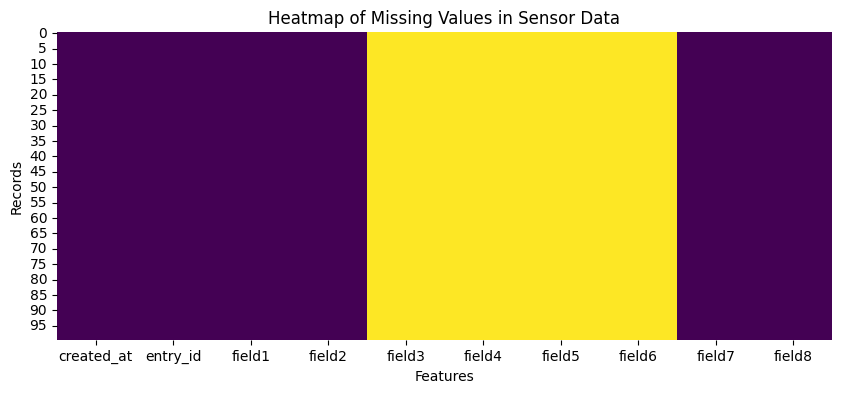

In [ ]:
# 1. Heatmap for df_sensor
plt.figure(figsize=(10, 4))
sns.heatmap(df_sensor.isnull(), cbar=False, cmap="viridis")
plt.title("Heatmap of Missing Values in Sensor Data")
plt.xlabel("Features")
plt.ylabel("Records")
plt.show()

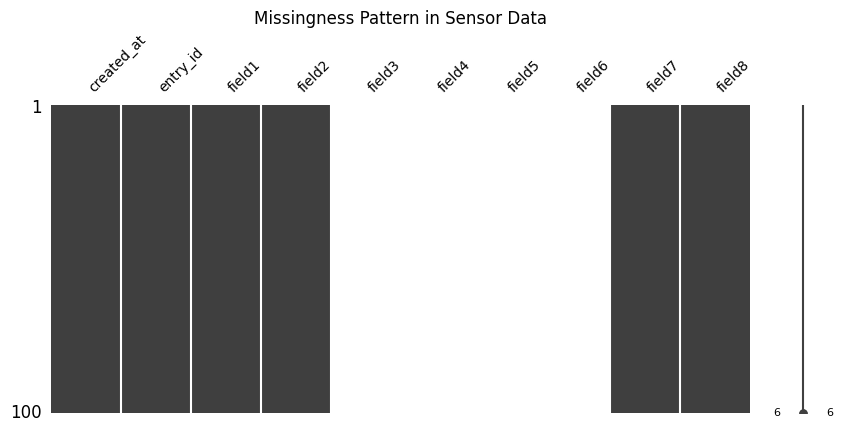

In [ ]:
# 2. Missingno Matrix for df_sensor
msno.matrix(df_sensor, figsize=(10, 4), fontsize=10)
plt.title("Missingness Pattern in Sensor Data")
plt.show()

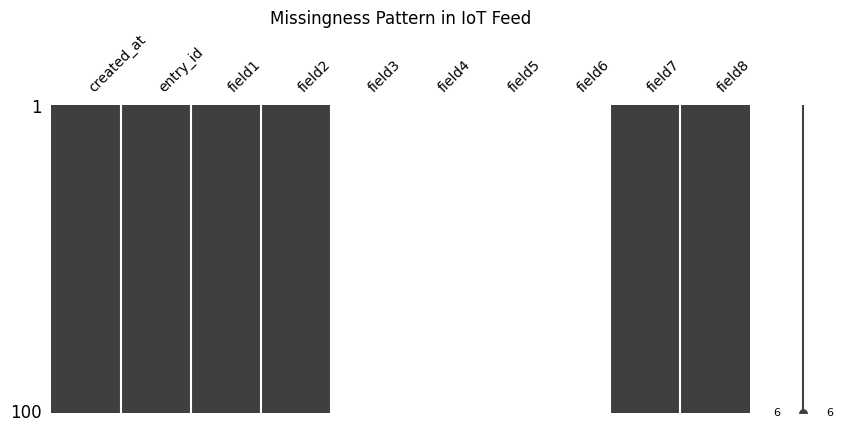

In [ ]:
# 3. Missingno Matrix for df_iot (real-time API logs)
msno.matrix(df_iot, figsize=(10, 4), fontsize=10)
plt.title("Missingness Pattern in IoT Feed")
plt.show()

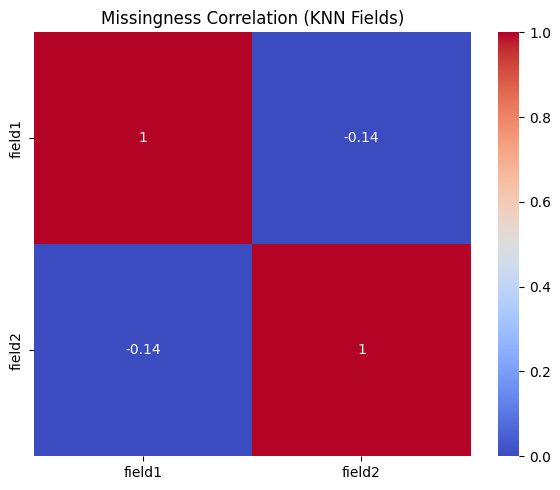

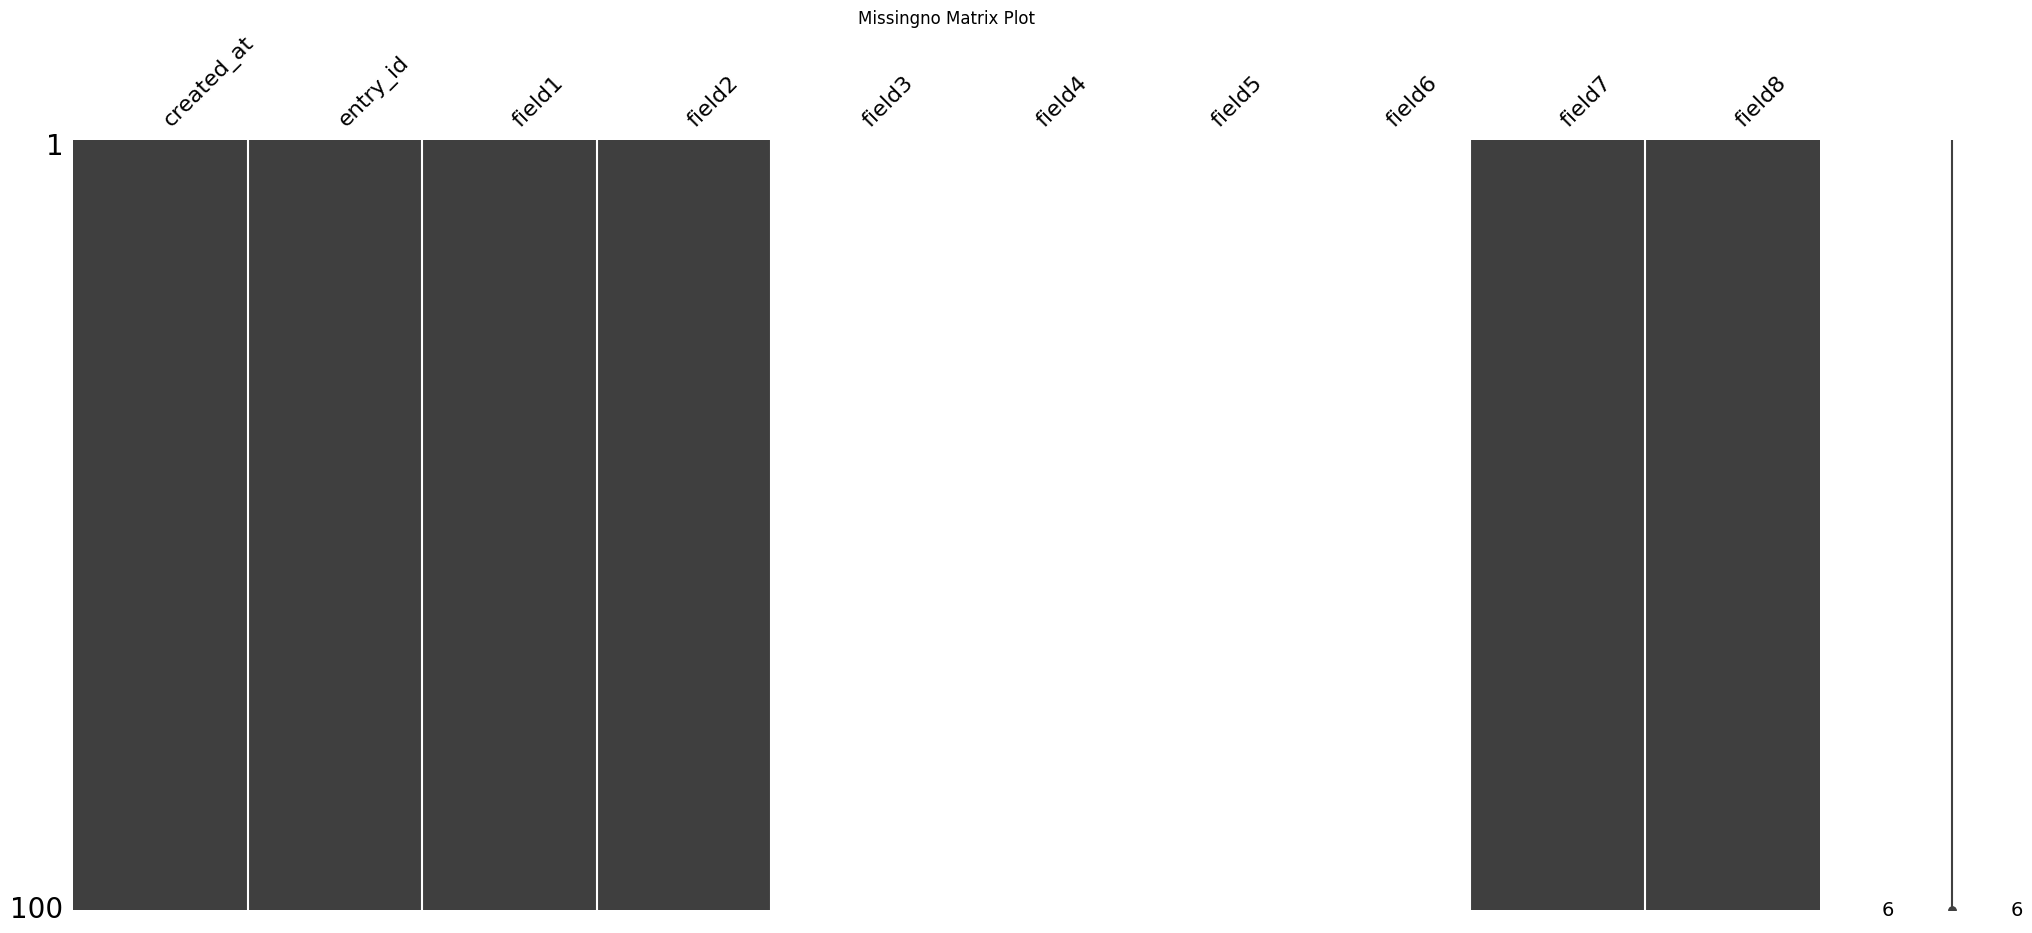

In [ ]:
# 4. Correlation Heatmaps of Missingness

# Use df_knn which has sufficient missing values from Experiment 4
missing_corr = df_knn.isnull().corr()

plt.figure(figsize=(6, 5))
sns.heatmap(missing_corr, annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Missingness Correlation (KNN Fields)")
plt.tight_layout()
plt.show()

msno.matrix(df_iot)
plt.title("Missingno Matrix Plot")
plt.show()

# Experiment 6: Model Accuracy on raw vs. imputed sensor data

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [ ]:
# Binary classification label based on field1 median
threshold = df_knn['field1'].median()
df_knn['label'] = np.where(df_knn['field1'] > threshold, 1, 0)
df_knn_imputed['label'] = np.where(df_knn_imputed['field1'] > threshold, 1, 0)


In [ ]:
# Drop rows with missing values in raw data
df_knn_clean = df_knn.dropna()

In [ ]:
# Split raw data (with missing dropped)
X_raw = df_knn_clean.drop(columns=['label'])
y_raw = df_knn_clean['label']
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_raw, y_raw, stratify=y_raw, random_state=1)

In [ ]:
# Split imputed data
X_imp = df_knn_imputed.drop(columns=['label'])
y_imp = df_knn_imputed['label']
Xi_train, Xi_test, yi_train, yi_test = train_test_split(X_imp, y_imp, stratify=y_imp, random_state=1)

In [ ]:
# Train on raw (dropped missing)
clf_raw = DecisionTreeClassifier(random_state=1)
clf_raw.fit(Xr_train, yr_train)
yr_pred = clf_raw.predict(Xr_test)


In [ ]:
# Train on imputed data
clf_imp = DecisionTreeClassifier(random_state=1)
clf_imp.fit(Xi_train, yi_train)
yi_pred = clf_imp.predict(Xi_test)

In [ ]:
# Mean Imputation
from sklearn.impute import SimpleImputer
mean_imputer = SimpleImputer(strategy='mean')
df_knn_mean_imputed = df_knn.copy()
df_knn_mean_imputed.iloc[:, :-1] = mean_imputer.fit_transform(df_knn_mean_imputed.iloc[:, :-1])

In [ ]:
# Generate labels for mean-imputed data (same logic)
df_knn_mean_imputed['label'] = np.where(df_knn_mean_imputed['field1'] > threshold, 1, 0)

In [ ]:
# Train-test split for mean-imputed
X_mean = df_knn_mean_imputed.drop(columns=['label'])
y_mean = df_knn_mean_imputed['label']
Xm_train, Xm_test, ym_train, ym_test = train_test_split(X_mean, y_mean, stratify=y_mean, random_state=1)

In [ ]:
# Train and evaluate classifier on mean-imputed data
clf_mean = DecisionTreeClassifier(random_state=1)
clf_mean.fit(Xm_train, ym_train)
ym_pred = clf_mean.predict(Xm_test)

In [ ]:
# Accuracy for raw data (missing dropped)
print("Accuracy on raw data (missing dropped):", accuracy_score(yr_test, yr_pred))
# Accuracy for mean-imputed data
print("Accuracy on mean-imputed data:", accuracy_score(ym_test, ym_pred))
# Accuracy for KNN-imputed data
print("Accuracy on KNN-imputed data:", accuracy_score(yi_test, yi_pred))

Accuracy on raw data (missing dropped): 0.9473684210526315
Accuracy on mean-imputed data: 1.0
Accuracy on KNN-imputed data: 1.0


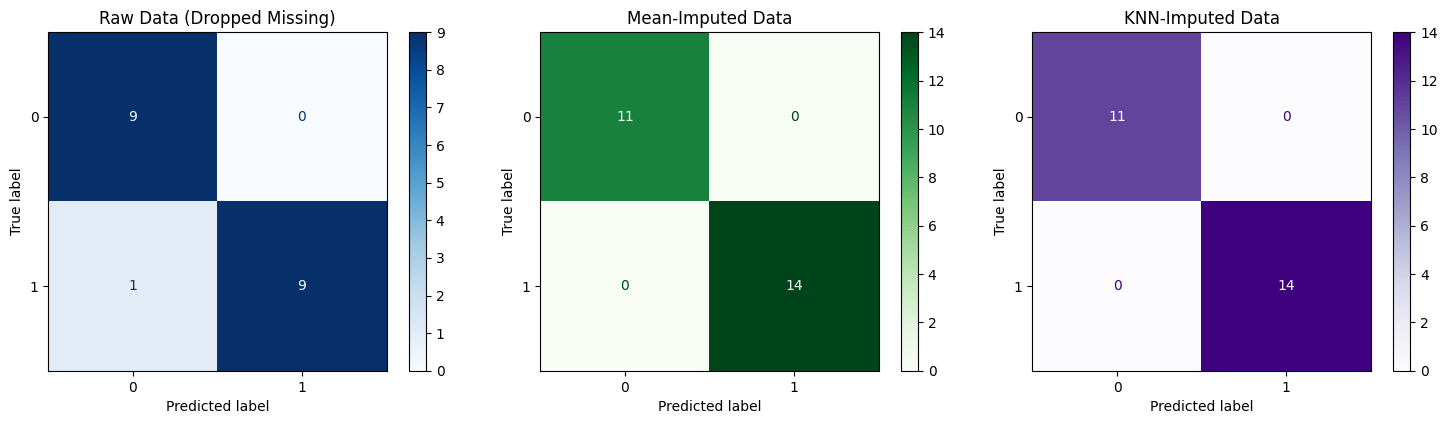

Accuracy on imputed data (KNN): 1.0


In [ ]:
# Confusion Matrix Visualization for All
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay.from_estimator(clf_raw, Xr_test, yr_test, ax=axes[0], cmap='Blues')
axes[0].set_title("Raw Data (Dropped Missing)")

ConfusionMatrixDisplay.from_estimator(clf_mean, Xm_test, ym_test, ax=axes[1], cmap='Greens')
axes[1].set_title("Mean-Imputed Data")

ConfusionMatrixDisplay.from_estimator(clf_imp, Xi_test, yi_test, ax=axes[2], cmap='Purples')
axes[2].set_title("KNN-Imputed Data")

plt.tight_layout()
plt.show()
print("Accuracy on imputed data (KNN):", accuracy_score(yi_test, yi_pred))